In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_baywheels_df.csv")
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_hour,start_day,start_month,route_id
0,28929E5AFD15A2FB,electric_bike,2024-12-02 17:51:35.798,2024-12-02 17:54:29.841,O'Farrell St at Masonic Ave,SF-H16,Page St at Masonic Ave,SF-K16,37.781131,-122.447374,37.771135,-122.445341,member,17,Monday,12,SF-H16-SF-K16
1,5FC879CAC379C364,electric_bike,2024-12-30 12:01:54.081,2024-12-30 12:34:35.126,Greenwich St at Franklin St,SF-B21,Mason St at Halleck St,SF-A15,37.800287,-122.425786,37.803968,-122.455079,casual,12,Monday,12,SF-B21-SF-A15
2,7BF609D17E4AE925,electric_bike,2024-12-24 07:59:08.908,2024-12-24 08:01:14.056,San Francisco Public Library,SF-I24,Grove St at Gough St,SF-J22-2,37.778799,-122.415963,37.777870,-122.422953,member,7,Tuesday,12,SF-I24-SF-J22-2
3,9DEA637C58FBDDBA,electric_bike,2024-12-29 15:19:35.704,2024-12-29 15:26:32.882,Market St at Franklin St,SF-K22-1,Church St at Duboce Ave,SF-L20,37.773793,-122.421239,37.769818,-122.429148,member,15,Sunday,12,SF-K22-1-SF-L20
4,BD56E9D0CDA65000,classic_bike,2024-12-21 16:44:18.909,2024-12-21 16:46:07.511,Parker St at Fulton St,BK-F8,Parker St at Fulton St,BK-F8,37.862464,-122.264791,37.862464,-122.264791,member,16,Saturday,12,BK-F8-BK-F8


### Behavioral Proxy Analysis

#### Churn and Retention
Exploring users who buy subscriptions and don't.

1. Identifying "Tourist" vs "Commuter"
To simulate "users" I will look for patterns that suggest repeated behavior. 
I will focus on:
- The "casual" and "member" split. Members are retained base; casuals are potential tourists/churn.
- Station Pairings. Identifying "commute corridors" (e.g. Station A - Station B every morning) VS "Tourist Loops" (e.g. starting and ending at the same location)

In [3]:
df["is_round_trip"] = df["start_station_id"] == df["end_station_id"]
tourist_proxy = df.groupby("member_casual")["is_round_trip"].mean() * 100
print(f"Percentage of Round Trips:\n{tourist_proxy}")

Percentage of Round Trips:
member_casual
casual    6.141888
member    1.721615
Name: is_round_trip, dtype: float64


*Conclusion:* Casual Riders are ~3x more likely to be riding for sighseeing or experience (round trips) than Members, who are likely using bikes for point-to-point utility or commuting.

2. Time-to-Second-Ride
Since I can't calculate this per user, I'll look at the density of rides at specific stations. If a station has a high volume of "casual" riders but a very low "return rate" (trip coming back to that station) I can infer high churn for that location

In [4]:
station_stats = df.groupby(["start_station_id", "start_station_name"]).agg(
    total_rides=('ride_id', 'count'),
    member_rides=('member_casual', lambda x: (x=='member').sum()),
    casual_rides=('member_casual', lambda x: (x=='casual').sum()),
    round_trips=('is_round_trip', 'sum')
).reset_index()

# include those station that has at least 30 rides
station_stats = station_stats[station_stats["total_rides"] >= 30]

In [5]:
# calculate ratios of member and round rides
station_stats["member_pct"] = (station_stats["member_rides"] / station_stats["total_rides"]) * 100
station_stats["round_trip_pct"] = (station_stats["round_trips"] / station_stats["total_rides"]) * 100

# for touristic places we assume at least 1000 rides
tourist_hubs = station_stats[station_stats["total_rides"] >= 1000].sort_values(by=["round_trip_pct", "total_rides"], ascending=False)

print("Supposed touristic hubs:")
print(tourist_hubs[["start_station_name", "total_rides", "member_pct", "round_trip_pct"]].head(10))

Supposed touristic hubs:
               start_station_name  total_rides  member_pct  round_trip_pct
169                Brooklyn Basin         1242   47.745572       36.392915
558    Lincoln Blvd at Hoffman St        11178   20.352478       24.118805
507   Great Highway at Taraval St         4809   43.189852       23.435226
607     23rd St at Santa Clara St         1065   79.154930       22.441315
556       Font Blvd at Arballo Dr         1234   48.622366       17.179903
179         Crissy Field Overlook         2511   29.430506       16.686579
557  Holloway Ave at Arellano Ave         1229   58.421481       16.192026
592              Saint James Park         1020   77.843137       15.980392
178             West Crissy Field        13800   40.949275       13.695652
497  Quintara St at Great Highway         1518   48.287220       13.504611


I have uncovered the following insights:
- Stations like *West Crissy Field* and *Lincoln Blvd at Hoffman St* have massive volume of rides (11-13K) with relatively low number of members (20-40%) combined with high number of round trips confirms these are "Experience" stations - people rent bikes to see the Bridge and bring it back.
- Looking at *23rd St at Santa Clara St* and *Saint James Park* with highest percent of members (~78%) and with also relatively high numbers of round trips (~16-22%). These might be not the tourists but locals taking the bike out for recreational loop.

In [6]:
commuter_hubs = station_stats.sort_values(by=["member_pct", "round_trip_pct"], ascending=[False, True])

print("Supposed commuter routes:")
commuter_hubs[["start_station_name", "total_rides", "member_pct", "round_trip_pct"]].head(10)

Supposed commuter routes:


,start_station_name,total_rides,member_pct,round_trip_pct
73,Howard Internal Monolith,237,100.000000,78.481013
74,Firmware Test Charging Internal Howard,44,100.000000,88.636364
175,Minnesota St Depot (Outgoing),152,98.026316,0.657895
590,N Morrison Ave at W Julian St,4182,94.906743,4.854137
632,5th St at Virginia St,2951,93.087089,6.675703
605,San Fernando St at 7th St,8293,93.054383,4.304835
401,Division St at Potrero Ave,18966,91.553306,0.616893
601,San Fernando St at 4th St,9946,91.413634,7.369797
604,Santa Clara St at 7th St,3331,91.143801,3.692585
639,Bestor Art Park,1080,90.462963,4.259259


We can see some outliers with low number of rides, high percentage of membership (~100%) and high percentage of round rides (~80-90%). Looking at the names ("Howard Internal Monolith", "Firmware Test Charging Internal Howard") I make an assumption they were "test rides". To remove outliers I use the IQR method.

In [7]:
# lower bound = Q1 - 1.5 * IQR
# higher bound = Q3 + 1.5 * IQR

volume_threshold = station_stats["total_rides"].quantile(0.25)
filtered_df = station_stats[station_stats["total_rides"] > volume_threshold].copy()

# function to find the bounds using IQR
def get_outlier_bounds(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_b = q1 - 1.5 * iqr
    higher_b = q3 + 1.5 * iqr
    return lower_b, higher_b

# appply outliers function to membership percentage
mem_lower, mem_upper = get_outlier_bounds(filtered_df, "member_pct")
round_lower, round_upper = get_outlier_bounds(filtered_df, "round_trip_pct")

clean_data = filtered_df[
    (filtered_df["member_pct"] >= mem_lower) & (filtered_df["member_pct"] <= mem_upper) &
    (filtered_df["round_trip_pct"] >= round_lower) & (filtered_df["round_trip_pct"] <= round_upper)
]

In [8]:
commuter_hubs = clean_data.sort_values(by=["member_pct", "round_trip_pct"], ascending=[False, True])

print("Supposed commuter routes:")
commuter_hubs[["start_station_name", "total_rides", "member_pct", "round_trip_pct"]].head(10)

Supposed commuter routes:


,start_station_name,total_rides,member_pct,round_trip_pct
590,N Morrison Ave at W Julian St,4182,94.906743,4.854137
632,5th St at Virginia St,2951,93.087089,6.675703
605,San Fernando St at 7th St,8293,93.054383,4.304835
401,Division St at Potrero Ave,18966,91.553306,0.616893
601,San Fernando St at 4th St,9946,91.413634,7.369797
604,Santa Clara St at 7th St,3331,91.143801,3.692585
639,Bestor Art Park,1080,90.462963,4.259259
587,2nd St at Julian St,2340,89.957265,5.683761
380,Otis St at Brady St,10944,89.839181,1.827485
481,22nd St at Potrero Ave,9188,89.627775,1.795821


Now I look into the seasonality index. I calculate a Coefficient of Variation (CV) for the monthly ride counts. A high CV means the station is highly seasonal (unstable), while a low CV means it's reliable, retained commuter spot.
<br>
*CV = Std/Mean*

In [9]:
monthly_counts = df.groupby(["start_station_name", "start_month"]).size().unstack(fill_value=0)
seasonality = monthly_counts.std(axis=1) / monthly_counts.mean(axis=1)
seasonality_df = seasonality.reset_index(name="seasonality_index")
final_analysis = station_stats.merge(seasonality_df, on="start_station_name")
final_analysis.sort_values("seasonality_index").head(10)


,start_station_id,start_station_name,total_rides,member_rides,casual_rides,round_trips,member_pct,round_trip_pct,seasonality_index
494,SF-R26,Potrero del Sol Park,5718,4728,990,152,82.686254,2.658272,0.103775
397,SF-L28,Berry St at King St,8900,7820,1080,174,87.865169,1.955056,0.125902
381,SF-K29-1,Berry St at 4th St,23763,20471,3292,406,86.146530,1.708538,0.132658
459,SF-O24,Folsom St at 19th St,15314,13332,1982,122,87.057594,0.796657,0.133730
315,SF-H30-2,Delancey St at Brannan St,11624,9911,1713,204,85.263248,1.754990,0.134468
384,SF-K30-3,4th St at Long Bridge St,22912,19410,3502,355,84.715433,1.549406,0.140252
493,SF-R24,Garfield Square,14889,12442,2447,283,83.565048,1.900732,0.142052
470,SF-P24,Harrison St at 20th St,15007,12901,2106,174,85.966549,1.159459,0.142996
419,SF-M22-1,14th St at Mission St,10033,8429,1604,147,84.012758,1.465165,0.143019
380,SF-K28-3,Townsend St at 6th St,4669,4098,571,63,87.770401,1.349325,0.147495


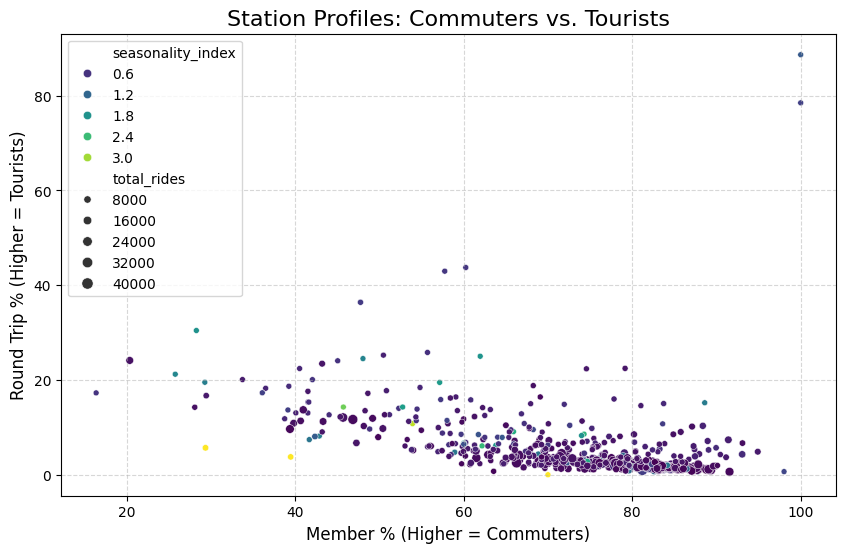

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_analysis,
    x="member_pct",
    y="round_trip_pct",
    size="total_rides",
    hue="seasonality_index",
    palette="viridis"
)

plt.title('Station Profiles: Commuters vs. Tourists', fontsize=16)
plt.xlabel('Member % (Higher = Commuters)', fontsize=12)
plt.ylabel('Round Trip % (Higher = Tourists)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

*Insight:*
- The higher % of memberships correlated with lower % of round trips. Which points to the conclusion that most people who are not members are not regualar commuters.

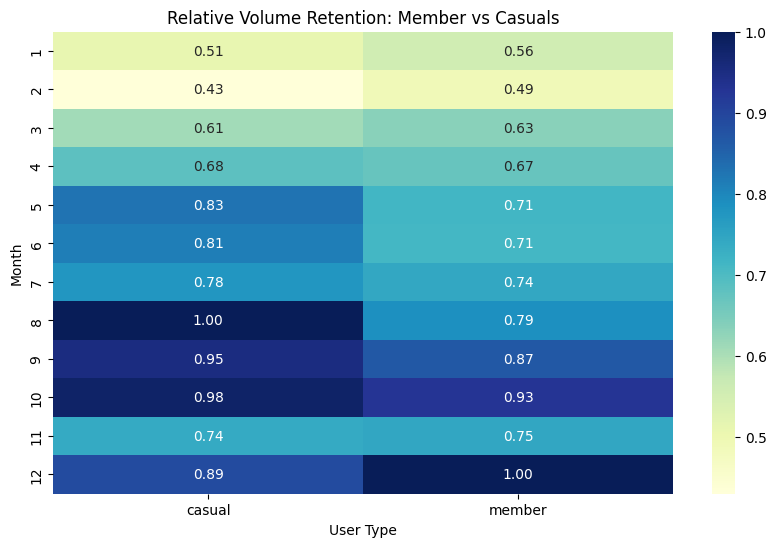

In [11]:
heat_data = df.groupby(["start_month", "member_casual"]).size().unstack()
heat_norm = heat_data.div(heat_data.max())

plt.figure(figsize=(10,6))
sns.heatmap(heat_norm, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Relative Volume Retention: Member vs Casuals")
plt.xlabel("User Type")
plt.ylabel("Month")
plt.show()

Look into the October-November drop.

In [12]:
monthly_user_type = df.groupby(['start_month', 'member_casual']).size().unstack()
retention_trends = monthly_user_type.pct_change() + 1 
print("Retention Rate from October to November:")
print(retention_trends.loc[11])

Retention Rate from October to November:
member_casual
casual    0.753941
member    0.804042
Name: 11, dtype: float64


Casual riders are 5% more likely ro "churn" as soon as the calendar hits November. Members are dedicated commuters who keep riding even with the change in season.
Casual retention still is quite high, they're most definitely un-subscribed residents that use bikes semi-regularly.

#### Onboarding Quality
Looking into "return rate" and specifics of short rides.

I will bucket the ride duration and thne look at the "Return Rate" - how often does a ride starting at station A and ending at station B resul in another ride starting from station B within a short window?

In [13]:
df["trip_duration_min"] = (pd.to_datetime(df["ended_at"]) - pd.to_datetime(df["started_at"])).dt.total_seconds() / 60

In [14]:
bins = [0,3,15,30,float('inf')]
labels = ["<3 mins", "3-15 mins", "15-30 mins", "30+ mins"]
df["duration_bucket"] = pd.cut(df["trip_duration_min"], bins=bins, labels=labels)

onboarding_dist = df.groupby(["duration_bucket", "member_casual"]).size().unstack()
print(onboarding_dist)

member_casual    casual   member
duration_bucket                 
<3 mins           42831   327081
3-15 mins        546817  2592135
15-30 mins       258157   598489
30+ mins         145533   105037


/var/folders/r3/fhz0cy092rq1vdp607ycp5zc0000gn/T/ipykernel_8667/3034037671.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  onboarding_dist = df.groupby(["duration_bucket", "member_casual"]).size().unstack()


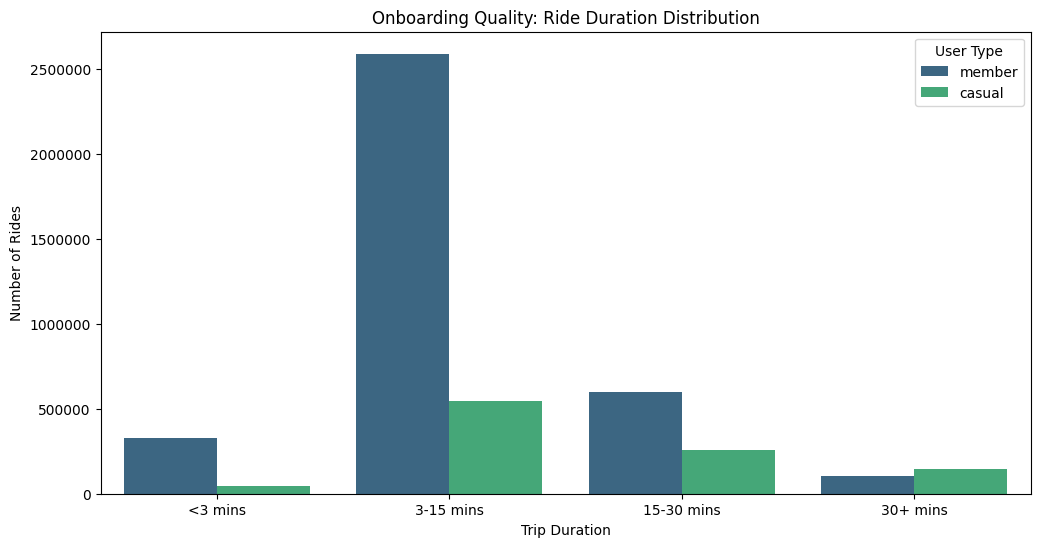

In [15]:
plt.figure(figsize=(12,6))
plt.style.use("seaborn-v0_8-muted")
ax1 = sns.countplot(data=df, x="duration_bucket", hue="member_casual", order=labels, palette="viridis")
plt.title("Onboarding Quality: Ride Duration Distribution")
plt.xlabel("Trip Duration")
plt.ylabel("Number of Rides")

plt.legend(title="User Type")

ax1.ticklabel_format(axis="y", style="plain")
plt.show()

3-15 minutes drive is the "sweet spot". It's long enough to enjoy the service but short enough to fell efficient. Those that take long trips 30+ minutes don't subscribe, might be because they use bikes only for rare long trips.

Look into <3 minutes ride. I can test if it's a technical failure or a last-mile success. Here's how I define "technical failure" vs. "success":
<br>
- \<3 mins AND starts/ends at the same station = high chance it's a technical failure
- \<3 mins AND ends at a different station = bike-share system is being used for "micro-mobility"


In [16]:
short_rides = df[df["trip_duration_min"] < 3].copy()
short_rides["is_same_station"] = short_rides["start_station_id"] == short_rides["end_station_id"]

failure_vs_success = short_rides.groupby(["is_same_station", "member_casual"]).size().unstack()
print("Short Ride (<3 min) Analysis:")
print(failure_vs_success)

Short Ride (<3 min) Analysis:
member_casual    casual  member
is_same_station                
False             30015  298854
True              12837   28247


**Insights.**
<br>
"Last-mile" success:
- Members: 298854 rides from one station to another. I suggest the products is succeeding as a high-speed walking substitute.
- Casuals: 30015 rides.
<br>

"The technical failure":

- Casuals: 12837 rides compared to 30015 means that for every ~2(2.3) successful short trips a casual rider takes they have 1 "failed" trip.
- Members: even though the raw number is higher, it's only 9% of their total short trips. Members are either: better at spotting a bad bike before unlocking it or they are more patient (because they already pay for a subscription).

**Conclusion:** For a Casual user, short round trip is likely their first and last interaction with the brand if the bike was broken. They spent money to unlock a bike, realized the seat was loose or the tire was flat, and docked it immediately.

**Recommendation:** Onboarding UX to encourage "pre-ride check" (check tires/brakes) to ensure the first experience isn't a 2-minute round trip.

In [17]:
short_rides.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'start_hour', 'start_day', 'start_month', 'route_id',
       'is_round_trip', 'trip_duration_min', 'duration_bucket',
       'is_same_station'],
      dtype='object')

In [18]:
problem_stations = short_rides.groupby(["start_station_name", "start_station_id"]).agg(
    total_rides=("ride_id", "count"),
    round_trips=("is_round_trip", "sum")
).reset_index()

# need to have at least 500 rides to avoid 100% of failure rate
problem_stations = problem_stations[problem_stations["total_rides"] > 500]

In [19]:
problem_stations["failure_rate"] = problem_stations["round_trips"] / problem_stations["total_rides"] * 100
problem_stations.sort_values(by="failure_rate", ascending=False).head(10)

,start_station_name,start_station_id,total_rides,round_trips,failure_rate
347,JFK Dr at Great Highway,SF-GGP-05,733,384,52.387449
117,8th Ave at JFK Dr,SF-GGP-03,1069,560,52.385407
476,Pompei Circle at JFK Dr,SF-GGP-01,872,425,48.738532
383,Lincoln Blvd at Graham St,SF-B14,525,250,47.619048
446,North Point St at Polk St,SF-A22,1075,469,43.627907
470,Pier 1/2 at The Embarcadero,SF-D29,789,267,33.840304
447,North Point St at Powell St,SF-A25,796,261,32.788945
259,Fell St at Stanyan St,SF-K15-,650,209,32.153846
391,Lyon St at Lombard St,SF-C16-2,638,190,29.780564
186,Buchanan St at North Point St,SF-A20,1113,323,29.020665


Next, I'll try to separate "Technical Failures" from "Exploration". Hypothesis is as following:
- if it's a technical failure, the rate should be the same on the work days and weekends (for example on Tuesday and Sunday)
- if it's exploration, the rate will skyrocket on weekends (Sat/Sun)

In [20]:
short_rides["is_weekend"] = np.where(short_rides["start_day"].isin(["Saturday", "Sunday"]), "Weekend", "Weekday")
context_dive = short_rides.groupby(["start_station_name", "is_weekend"]).agg(
    total_rides=("ride_id", "count"),
    round_trips=("is_round_trip", "sum")
).unstack()

# filter for at least 500 rides
context_dive = context_dive[context_dive["total_rides"].sum(axis=1) > 500]

context_dive["failure_rate_weekday"] = (context_dive[("round_trips", "Weekday")] / context_dive[("total_rides", "Weekday")]) * 100
context_dive["failure_rate_weekend"] = (context_dive[("round_trips", "Weekend")] / context_dive[("total_rides", "Weekend")]) * 100

context_dive["weekend_diff"] = context_dive["failure_rate_weekend"] - context_dive["failure_rate_weekday"]
context_dive.sort_values(by="weekend_diff", ascending=False).head(10)

total_rides         round_trips          \
is_weekend                        Weekday Weekend     Weekday Weekend   
start_station_name                                                      
Pier 1/2 at The Embarcadero         635.0   154.0       184.0    83.0   
The Embarcadero at Vallejo St       509.0    53.0        67.0    19.0   
San Francisco Ferry Building        905.0   307.0       201.0   137.0   
Lincoln Blvd at Graham St           361.0   164.0       147.0   103.0   
Lyon St at Lombard St               479.0   159.0       117.0    73.0   
Waller St at Shrader St             961.0   462.0       194.0   181.0   
North Point St at Powell St         608.0   188.0       175.0    86.0   
Fell St at Stanyan St               424.0   226.0       112.0    97.0   
Washington St at Kearny St          622.0   190.0       142.0    73.0   
Pompei Circle at JFK Dr             495.0   377.0       208.0   217.0   

                              failure_rate_weekday failure_rate_weekend  \
is_weekend                                                                
start_station_name                                                        
Pier 1/2 at The Embarcadero              28.976378            53.896104   
The Embarcadero at Vallejo St            13.163065            35.849057   
San Francisco Ferry Building             22.209945            44.625407   
Lincoln Blvd at Graham St                40.720222            62.804878   
Lyon St at Lombard St                    24.425887            45.911950   
Waller St at Shrader St                  20.187305            39.177489   
North Point St at Powell St              28.782895            45.744681   
Fell St at Stanyan St                    26.415094            42.920354   
Washington St at Kearny St               22.829582            38.421053   
Pompei Circle at JFK Dr                  42.020202            57.559682   

                              weekend_diff  
is_weekend                                  
start_station_name                          
Pier 1/2 at The Embarcadero      24.919726  
The Embarcadero at Vallejo St    22.685992  
San Francisco Ferry Building     22.415462  
Lincoln Blvd at Graham St        22.084656  
Lyon St at Lombard St            21.486062  
Waller St at Shrader St          18.990184  
North Point St at Powell St      16.961786  
Fell St at Stanyan St            16.505260  
Washington St at Kearny St       15.591471  
Pompei Circle at JFK Dr          15.539480

I make a conclusion that on these stations above the high "failure rate" is explainable by "leisure explorers", which is why short round trips jump on weekends by averagely 22-24%.

#### Loyalty Behavior
Defining the Member Archetype.

If we know exactly how subscribers act we can spot the "casual" members who are ready (or soon-to-be) converted. The strategy to create a "gold standard" of behavior:
- Temporal: What hour do they start?
- Directional: Do they actually go somewhere? (point-to-point ratio)
- Speed/Efficiency: How long is the ride? (My prediction from earlier analysis, the window is 3-15 minutes)
- Consistency: Weekday Vs. Weekend Balance

In [21]:
# create a rush hour and weekday flag
df["is_rush_hour"] = df["start_hour"].isin([7, 8, 9, 16, 17, 18])
df["is_weekday"] = ~df["start_day"].isin(["Saturday", "Sunday"])

In [22]:
behavior_df = df.groupby("member_casual").agg(
    avg_duration=("trip_duration_min", "mean"),
    med_duration=("trip_duration_min", "median"),
    rush_hour_pct=("is_rush_hour", "mean"),
    weekday_pct=("is_weekday", "mean"),
    round_trip_pct=("is_round_trip", "mean")
)

cols_to_pct = ["rush_hour_pct", "weekday_pct", "round_trip_pct"]
behavior_df[cols_to_pct] = behavior_df[cols_to_pct] * 100

behavior_df

,avg_duration,med_duration,rush_hour_pct,weekday_pct,round_trip_pct
member_casual,,,,,
casual,21.074996,12.398017,39.266771,64.264480,6.141888
member,11.079607,8.502350,47.715859,77.923281,1.721615


In [34]:
rideable_pref = df.groupby(["member_casual", "rideable_type"]).size().unstack(fill_value=0)
rideable_pref_pct = rideable_pref.div(rideable_pref.sum(axis=1), axis=0) * 100
rideable_pref_pct

rideable_type,classic_bike,electric_bike
member_casual,,
casual,21.853127,78.146873
member,20.838548,79.161452


Both members and casuals (~80%) use electric bikes more often than classic bikes.

**Insights**.
<br>

*The Member:*
- Median ride is only 8.5 mins, they're moving between points with high efficiency.
- Predictable - Nearly 78% of their rides happend during the work week and almost half (47.7%) during rush hour.
- Remarkable low round-trip rate of 1.7%. The bike for Members is most likely a tool for transportation, not recreation.
- High-frequency, short-duration, weekday-heavy, point-to-point utility.

*The Casual:*
- The average duration is double of a member (21 vs 11). Even their median is 50% higher. May be people who are using biking as exercising.
- They're less likely to ride during rush hour (39%).
- 3.5x more likely to go on a round trip (6.1%) than members. They are either tourists, people exercising or new users "trying out" the product.
- Low-frequency, long-duration, weekend-leaning, exploratory loops.

**Conclusion:** There's a Subset of Casual riders who represent 64% of casual volume on weekdays and roughly 39% during rush hour. They *act* like members. The Churn isn't a problem in the product, the subscription conversion is.

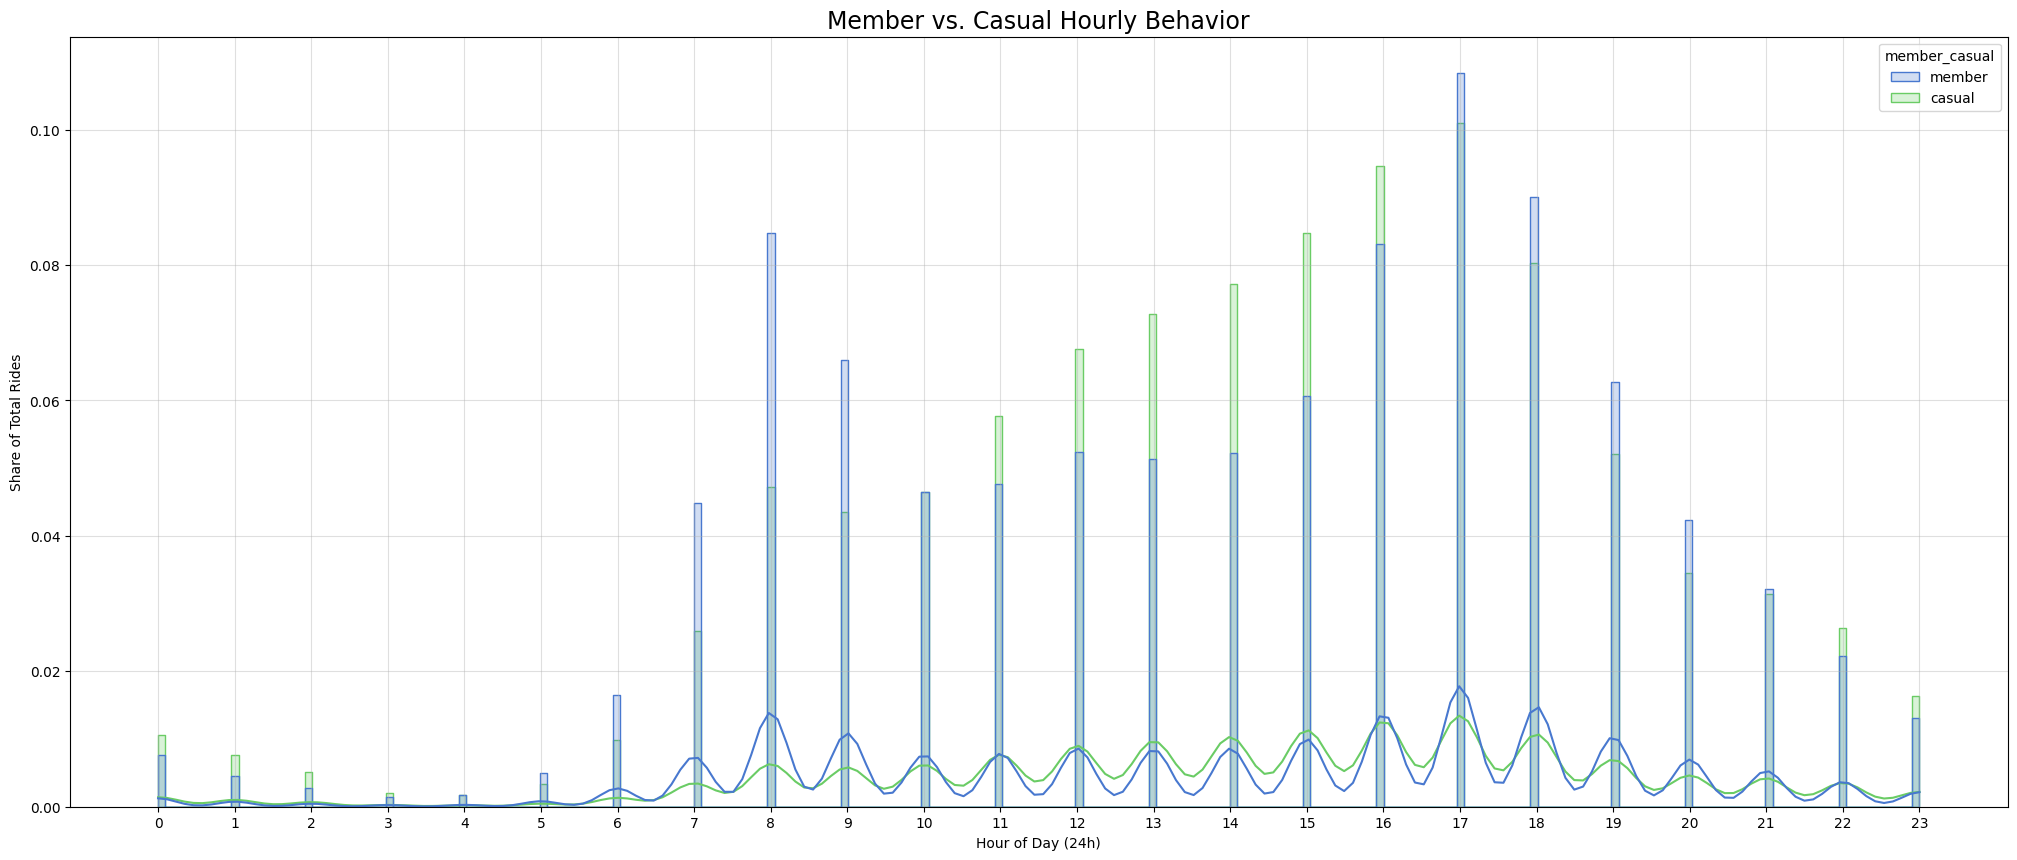

In [76]:
plt.figure(figsize=(25, 10))

sns.histplot(
    data=df,
    x="start_hour",
    hue="member_casual",
    stat="probability",
    common_norm=False,
    element="step",
    kde=True
)

plt.xticks(range(0, 24))
plt.title("Member vs. Casual Hourly Behavior", fontsize=17)
plt.xlabel("Hour of Day (24h)")
plt.ylabel("Share of Total Rides")
plt.grid(alpha=0.4)
plt.show()

In this graph above we can see the hourly dynamic of User's behavior based on their type (Member vs. Casual).